# **PROJETO ANÁLISE DE DADOS**
# Análise das Emissões de Carbono da Empresa Apple

---

## Análise com Banco de Dados MySQL

O projeto foi desenvolvido com o apoio de diferentes tecnologias, entre elas, banco de dados relacionais, que permitiu a visualização e interpretação dos *datasets*. Optando pelo MySQL, as consultas dentro de seu ambiente proporcionaram uma visão ampla e instrutivas dos dados, permitindo uma interpretação frutífera e gerar novas informações relevantes.

### 🗂️ **Criação do Banco de dados e Importação de *datasets***

Como primeira etapa, foi criado um banco de dados no MySQL Workbench chamado **apple_analysis**, responsável por armazenar e organizar as bases de dados utilizadas ao longo de todo o projeto.

Já a importação dos dados foi feita através do assistente de importação do 'MySQL Workbench', seguindo o seguinte fluxo:


1. No painel **Schemas**, clique com o botão direito sobre **Tables** e selecione **Table Data Import Wizard**.
2. Selecione o arquivo `.csv` correspondente à tabela que será importada.
3. Escolha a opção **Create a new table** e marque **Drop table if exists**, garantindo a substituição da tabela caso ela já exista.
4. Defina a codificação (**Encoding**) como **UTF-8** e mantenha selecionadas todas as colunas para importação.
5. Confirme a operação e aguarde a conclusão do processo.
6. Repita os mesmos passos para as demais tabelas do projeto.

**As tabelas importadas foram:**  

 **Nome original**        | **Nome no ambiente BD**           |
 ------------- |-------------|
 carbon_footprint_by_product.csv      | "carbon_footprints" |
 normalizing_factors.csv     | "normalizing_factors" |
 data_dictionary.csv | "data_dictionary" |
 greenhouse_gas_emissions.csv | "gas_emissions" |


---

### Conectando ao Servidor MySQL

#### Importanto Bibliotecas

In [2]:
import mysql.connector
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

#### Inserindo credenciais

In [ ]:
(Informações censuradas) Em caso do usuário querer verificar as etapas da análise, inserir as próprias informações para concetar-se com o MySQL

In [3]:
conn = mysql.connector.connect(
    host="localhost",
    user="######",
    password="########",
    database="apple_analysis"
)

cursor = conn.cursor()

In [4]:
pd.read_sql('SELECT * FROM gas_emissions', con=conn)

,Fiscal Year,Category,Type,Scope,Description,Emissions
0,2022,Corporate emissions,Gross emissions,Scope 1,"Natural gas, diesel, propane",39700
1,2022,Corporate emissions,Gross emissions,Scope 1,Fleet vehicles,12600
2,2022,Corporate emissions,Gross emissions,Scope 1,Other (R&D processes & refrigerant leaks),2900
3,2022,Corporate emissions,Gross emissions,Scope 2 (market-based),Electricity,0
4,2022,Corporate emissions,Gross emissions,Scope 2 (market-based),"Steam, heating, and cooling",3000
...,...,...,...,...,...,...
104,2015,Corporate emissions,Gross emissions,Scope 3,Employee commute,172970
105,2015,Product life cycle emissions,Gross emissions,Scope 3,Manufacturing (purchased goods and services),29600000
106,2015,Product life cycle emissions,Gross emissions,Scope 3,Product transportation (upstream and downstream),1300000
107,2015,Product life cycle emissions,Gross emissions,Scope 3,Product use (use of sold products),6600000


Com êxito conectamos ao ao servidor locar do MySQL e pdemos começar a nossa análise. 

Neste projeto, o MySQL serviu, principalmente, na etapa inicial da análise, nesse caso, na análise exploratória, onde temos as primeiras impressões dos dados e buscando entender o que eles mostram, verificando erros, destectando padrões e desenvolvendo as primeiras teorias.

In [5]:
def sql(query):
    return pd.read_sql(query, con=conn)

Função para simplificar os comandos em MySQL neste ambiente.

---

### 📊 **Validação e Visualização dos Dados**

#### AVALINDO TABELA DE EMISSÕES DE GASES

In [5]:
sql('DESCRIBE gas_emissions')

,Field,Type,Null,Key,Default,Extra
0,Fiscal Year,int,YES,,None,
1,Category,text,YES,,None,
2,Type,text,YES,,None,
3,Scope,text,YES,,None,
4,Description,text,YES,,None,
5,Emissions,int,YES,,None,


In [34]:
sql("""SELECT COUNT(*) AS Qntd
    FROM gas_emissions"""
   )

,Qntd
0,109


#### Verificando valores nulos

In [36]:
sql("""SELECT
    SUM(`Fiscal Year` IS NULL) AS anos_nulll,
    SUM(category IS NULL) AS categoria_null,
    SUM(`Type` IS NULL) AS tipo_null,
    SUM(Scope IS NULL) AS escopo_null,
    SUM(`Description` IS NULL) AS descricao_null,
    SUM(emissions IS NULL) AS emissao_null
    FROM gas_emissions;"""
   )

,anos_nulll,categoria_null,tipo_null,escopo_null,descricao_null,emissao_null
0,0.0,0.0,0.0,0.0,0.0,0.0


Segundo essa consulta, nesta base de dados, **não há valores nulos**.

Embora não haja valores nulos, há, em escopo, valores vázios, que representam as remoções de carbono. Após analisar esses valores, é possível concluir que o escopo não se aplica a esses "tipos de emissões", logo, não se trata de um erro e pode permanecer assim enquanto estamos cientes dessa condição.

#### Verificando registros duplicados

In [38]:
sql("""SELECT *, COUNT(*) 
    FROM gas_emissions
    GROUP BY `Fiscal Year`, Category, `Type`, Scope, `Description`, Emissions
    HAVING COUNT(*) > 1;"""
   )

,Fiscal Year,Category,Type,Scope,Description,Emissions,COUNT(*)


Nenhum dado é exposto, ou seja, **não há dados duplicados**.

#### Análisando Registros por ano

In [41]:
sql("""
    SELECT `Fiscal Year`, COUNT(*) AS qntd
    FROM gas_emissions
    GROUP BY `Fiscal Year`;"""
   )

,Fiscal Year,qntd
0,2022,17
1,2021,16
2,2020,16
3,2019,16
4,2018,16
5,2017,10
6,2016,9
7,2015,9


**Análise dos registros anuais**

A maioria segue um padrão de registros anuais, com excessão dos três primeiros anos, que possuem menos referências anuais, enquanto 2022 apresenta um registro a mais que os demais.Essa diferença pode estar relacionada à forma de registro ou à disponibilidade dos dados em cada período, mas sua causa não pode ser determinada apenas a partir desta análise.

#### Visualizando os Registros de Emissões

In [16]:
sql("""SELECT Emissions, `Fiscal Year`
    FROM gas_Emissions
    ORDER BY `Emissions`; """
   )

,Emissions,Fiscal Year
0,-500000,2021
1,-324100,2022
2,-167000,2021
3,-70000,2020
4,0,2022
...,...,...
104,18500000,2018
105,18900000,2019
106,21100000,2017
107,22800000,2016


**Análise das Emissões**

A consultas das emissões (*Emissons*) expõe um dado curioso, dentro da base de dados, há emissões negativas. Esses valores negativos a príncipio podem parecer um erro, mas é necessário uma consulta mais cautelosa para determinar se esses dados fazem sentido.

#### Entendendo os Escopos (Scope)

In [10]:
sql("""SELECT Scope, COUNT(*) AS qntd
    FROM gas_emissions
    GROUP BY Scope;"""
       )

,Scope,qntd
0,Scope 1,22
1,Scope 2 (market-based),13
2,Scope 3,64
3,,10


**Análise dos Escopos**

A consulta identifica três categorias de escopo: *Scope 1*, *Scope 2 (market-based)* e *Scope 3*, além de 10 registros sem classificação de escopo (que incluem as emissões negativas). Segundo o **"data_dictionary"**, o *Scope 3* contempla emissões relacionadas à cadeia de valor da empresa, incluindo bens e serviços adquiridos, transporte e distribuição, viagens a negócios, deslocamento de funcionários, uso dos produtos e fim de sua vida útil.

O *Scope 3* apresenta maor quantidade de registros.

In [54]:
sql("""SELECT Scope, 
    COUNT(*) AS qntd,
    ROUND(AVG(Emissions), 1) AS media_emissoes
    FROM gas_emissions
    GROUP BY Scope
    ORDER BY media_emissoes;"""
       )

,Scope,qntd,media_emissoes
0,,10,-106110.0
1,Scope 2 (market-based),13,10324.6
2,Scope 1,22,17160.5
3,Scope 3,64,3303470.8


Observando a média das emissões e seus respectivos escopos, é possível observar a concentração de emissões *Scope 3*. Além de apresentar registros que não possuem escopo, que incluem emissões negativas.

In [26]:
sql("""SELECT Scope, `Type`, `Description`
    FROM gas_emissions
    WHERE Scope = '';"""
   ).head(10)

,Scope,Type,Description
0,,Carbon removals,Corporate carbon offsets
1,,Carbon removals,Product carbon offsets
2,,Carbon removals,Corporate carbon offsets
3,,Carbon removals,Product carbon offsets
4,,Carbon removals,Corporate carbon offsets
5,,Carbon removals,Product carbon offsets
6,,Carbon removals,Corporate carbon offsets
7,,Carbon removals,Product carbon offsets
8,,Carbon removals,Corporate carbon offsets
9,,Carbon removals,Product carbon offsets


In [28]:
sql("""SELECT `Type`, SUM(Emissions) as emissoes
    FROM gas_emissions
    GROUP BY `Type`;"""
   )

,Type,emissoes
0,Gross emissions,211933880.0
1,Carbon removals,-1061100.0


**Registros sem Escopo e Dados negativos**

Após outra consulta, fica evidente que os registros sem classificação de escopo representam as remoções de carbono. Ou seja, os valores negativos representam essas compensações promovidas pela empresa, que contribuem para a diminuição de carbono na atmosfera e não configuram um erro na base de dados.

#### Descrição das Emissões (Description)

In [61]:
sql("""SELECT DISTINCT `Description`, Scope, COUNT(*) AS qntd
    FROM gas_emissions
    GROUP BY `Description`, Scope
    ORDER BY qntd DESC;"""
   )

,Description,Scope,qntd
0,"Natural gas, diesel, propane",Scope 1,8
1,Fleet vehicles,Scope 1,8
2,Electricity,Scope 2 (market-based),8
3,Business travel,Scope 3,8
4,Employee commute,Scope 3,8
5,Manufacturing (purchased goods and services),Scope 3,8
6,Product transportation (upstream and downstream),Scope 3,8
7,Product use (use of sold products),Scope 3,8
8,End-of-life processing,Scope 3,8
9,Other (R&D processes & refrigerant leaks),Scope 1,6


**Análise da Descrição**

Através desta consulta das descrições, podemos obervar com mais detalhes as ações da empresa Apple que emitem gases poluentes, sdentificando ao todo 16 descrições distintas. Essas categorias abrangem diferentes atividades relacionadas às emissões da Apple e podem ser exploradas posteriormente para compreender quais fontes possuem maior participação nas emissões totais.

#### Compreendendo os Tipos (Type)

In [62]:
sql("""SELECT `Type`, Scope, COUNT(*) AS qntd
    FROM gas_emissions
    GROUP BY `Type`, Scope;"""
   )

,Type,Scope,qntd
0,Gross emissions,Scope 1,22
1,Gross emissions,Scope 2 (market-based),13
2,Gross emissions,Scope 3,64
3,Carbon removals,,10


**Análise dos Tipos**

Por meio da consulta por tipo, é possível observar que há dois tipos diferentes, as "emissões brutas" e as "remoções de carbono", sendo o último tipo, como observado anteriormente, referente as dados que naõ pertecem aos outros escopos.

---

#### AVALIANDO TABELA DE DATAÇÕES DE CARBONO

In [63]:
sql('DESCRIBE carbon_footprints;')

,Field,Type,Null,Key,Default,Extra
0,Release Year,int,YES,,None,
1,Product,text,YES,,None,
2,Baseline Storage,int,YES,,None,
3,Carbon Footprint,int,YES,,None,


In [65]:
sql('SELECT COUNT(*) AS Qntd FROM carbon_footprints;')

,Qntd
0,10


In [74]:
sql('SELECT * FROM carbon_footprints ORDER BY `Release Year`;')

,Release Year,Product,Baseline Storage,Carbon Footprint
0,2015,iPhone 6s,32,54
1,2016,iPhone 7,32,56
2,2017,iPhone X,64,79
3,2017,iPhone 8,64,57
4,2018,iPhone Xs,64,70
5,2019,iPhone 11,64,72
6,2020,iPhone 12,64,70
7,2021,iPhone 13,128,64
8,2022,iPhone 14,128,61
9,2023,iPhone 15,128,56


**Análise das Datações de Carbono**

Sendo uma tabela mais enchuta, podemos avaliar os dados através de uma obervação cautelosa da tabela.

Aqui podemos observar que não há nenhum valor nulo, tampouco dados repetidos.

#### AVALIANDO OS FATORES DE NORMALIZAÇÃO

In [76]:
sql('DESCRIBE normalizing_factors;')

,Field,Type,Null,Key,Default,Extra
0,Fiscal Year,int,YES,,None,
1,Revenue,int,YES,,None,
2,Market Capitalization,int,YES,,None,
3,Employees,int,YES,,None,


In [77]:
sql('SELECT COUNT(*) AS Qntd FROM  normalizing_factors;')

,Qntd
0,8


In [78]:
sql("SELECT * FROM normalizing_factors;")

,Fiscal Year,Revenue,Market Capitalization,Employees
0,2022,394328,2490,164000
1,2021,365817,2450,154000
2,2020,274515,1720,147000
3,2019,260174,1090,137000
4,2018,265595,830,132000
5,2017,229234,740,123000
6,2016,215639,600,116000
7,2015,233715,580,110000


**Análise dos Fatores de Normalização**

Em uma análise inicial, não são observados valores nulos ou registros repetidos na tabela.

Observa-se uma tendência geral de crescimento nos fatores apresentados. A receita (*Revenue*) apresenta uma queda entre 2015 e 2016, mas retoma o crescimento a partir de 2017. Já a capitalização de mercado (*Market Capitalization*) e o número de funcionários (*Employees*) apresentam crescimento contínuo durante o período analisado.

### Conclusão da etapa

A avaliação inicial permitiu compreender a estrutura e as principais características das bases, além de verificar sua consistência. Foram identificadas as principais categorias, tipos, escopos e fontes de emissão, bem como algumas diferenças na quantidade de registros entre os anos. As tabelas complementares também apresentaram informações relevantes sobre receita, capitalização de mercado e número de funcionários. Com essa visão inicial, é possível avançar para a análise exploratória.

---

### 🧭 **Análise Exploratória**

Antes de partir para uma análise, é importante entender aquilo que estamos buscando. Para isso servem as perguntas de negócios. Definir objetivos claros permite conduzir a investigação de a extrair informações relevantes. Assim, a análise deste projeto pode ser guiada pelas seguintes questões: 

1. **A empresa apresentou reduções mensuráveis nas emissões ao longo do perídodo analisada?**
2. **A Apple está no ritmo necessário para atingir a meta de carbono zero até 2030?**
3. **A diminuição (se houver) das emissões teve impacto no crescimento ecocômico da empresa?**


#### Emissões Anuais

In [6]:
sql("""SELECT `Fiscal Year`, SUM(Emissions) AS emissoes_anuais
    FROM gas_emissions
    GROUP BY `Fiscal Year`
    ORDER BY `Fiscal Year` ASC;"""
   )

,Fiscal Year,emissoes_anuais
0,2015,38383470.0
1,2016,29579370.0
2,2017,27416300.0
3,2018,25136170.0
4,2019,25033730.0
5,2020,22524440.0
6,2021,22519400.0
7,2022,20279900.0


**Análise das Emissões anuais**

Através da consulta das emissões anuais da tabela *gas_emissions* é possível visualizar que há um tendência de queda nas emissões de gás carbônico, com cada ano apresentando menores índices de emissões. Com isso podemos concluir que houve redução nas emissões de gás carbônico emitidos pela empresa ao longo de 2015 e 2022. Mas podemos aprofundar nessa análise.

#### Visualização das Emissões por Categoria

In [7]:
sql("""SELECT category, SUM(emissions) AS emissoes_categoria,
    ROUND(
    	SUM(emissions) * 100 /
        (SELECT SUM(emissions) FROM gas_emissions),
        2 ) AS percentual 
    FROM gas_emissions
    GROUP BY category;"""
   )

,category,emissoes_categoria,percentual
0,Corporate emissions,2562780.0,1.22
1,Product life cycle emissions,208310000.0,98.78


De acordo com a tabela, há uma diferença expressiva nas emissões provenientes do ciclo de vida do produto (*Product life cycle emissions*), representando mais que 98% das emissões. Essa dispersão indica que a maior parte das emissões estão concentradas nessa categoria.

In [11]:
sql("""SELECT category, `Fiscal Year`, SUM(Emissions) as emissoes_anuais
    FROM gas_emissions
    GROUP BY Category, `Fiscal Year`
    ORDER BY `Fiscal Year`;"""
   )

,category,Fiscal Year,emissoes_anuais
0,Corporate emissions,2015,383470.0
1,Product life cycle emissions,2015,38000000.0
2,Corporate emissions,2016,379370.0
3,Product life cycle emissions,2016,29200000.0
4,Corporate emissions,2017,376300.0
5,Product life cycle emissions,2017,27040000.0
6,Corporate emissions,2018,586170.0
7,Product life cycle emissions,2018,24550000.0
8,Corporate emissions,2019,573730.0
9,Product life cycle emissions,2019,24460000.0


**Análise das Emissões por Categoria**

Essa tabela apresenta a diferença das emissões ao longo dos anos separadas por categoria. Mediante a esses dados, pode-se extrair que ambas as categorias tiveram redução nas emissões no período analisado, com destaque às Emissões da corporação (*Corporate emissions*), que passaram a representar valores negativos, ou seja, as remoções de carbono superou os níveis de emissões. O que confere com os objetivos da empresa.

##### > Por Tipo

In [35]:
sql("""SELECT `Type`, `Fiscal Year`, SUM(Emissions) AS total_emissoes
    FROM gas_emissions
    WHERE `Type` = 'Carbon removals'
    GROUP BY `Fiscal Year`
    ORDER BY total_emissoes DESC;"""
   )

,Type,Fiscal Year,total_emissoes
0,Carbon removals,2019,0.0
1,Carbon removals,2018,0.0
2,Carbon removals,2020,-70000.0
3,Carbon removals,2022,-324100.0
4,Carbon removals,2021,-667000.0


In [9]:
sql("""SELECT `Fiscal Year`, SUM(emissions) AS remocoes
    FROM gas_emissions
    WHERE `Type` = 'Carbon removals' AND emissions < 0
    GROUP BY `Fiscal Year` 
    ORDER BY remocoes DESC;"""
   )

,Fiscal Year,remocoes
0,2020,-70000.0
1,2022,-324100.0
2,2021,-667000.0


**Análise das Emissões por Tipo**

Não só as emissões de carbono diminuiram ao longo do período analisado, mas, de acordo com essa consulta, também houve aumento nas remoções de carbono, embora em 2022 tenha tido um valor menos expressivo nas remoções se comparado ao ano anterior, ainda é uma quantidade considerável superior aos demais anos. Além do mais, apenas a partir de 2020 que de fato houveram  registros de remoções de carbono, o que indica que são ações recentes, possivelmente relacionadas a um esforço para diminuir as emissões de carbono adotado pela empresa.

#### Emissões por Escopo (*Scope*)

In [6]:
sql("""SELECT `Fiscal Year`,
    	SUM(CASE WHEN Scope = 'Scope 1' THEN Emissions END) AS Scope1,
    	SUM(CASE WHEN Scope = 'Scope 2 (market-based)' THEN Emissions END) AS Scope2,
    	SUM(CASE WHEN Scope = 'Scope 3' THEN Emissions END) AS Scope3
    FROM gas_emissions
    GROUP BY `Fiscal Year`
    ORDER BY `Fiscal Year`;"""
   )

,Fiscal Year,Scope1,Scope2,Scope3
0,2015,28100.0,42460.0,38312910.0
1,2016,34370.0,41000.0,29504000.0
2,2017,47050.0,36250.0,27333000.0
3,2018,57440.0,8730.0,25070000.0
4,2019,52730.0,0.0,24981000.0
5,2020,47440.0,0.0,22547000.0
6,2021,55200.0,2780.0,23128420.0
7,2022,55200.0,3000.0,20545800.0


In [19]:
sql("""SELECT DISTINCT Scope, Description
    FROM gas_emissions
    WHERE Scope <> ''
    ORDER BY Scope, Description;"""
   )

,Scope,Description
0,Scope 1,Fleet vehicles
1,Scope 1,"Natural gas, diesel, propane"
2,Scope 1,Other (R&D processes & refrigerant leaks)
3,Scope 2 (market-based),Electricity
4,Scope 2 (market-based),"Steam, heating, and cooling"
5,Scope 3,Business travel
6,Scope 3,Employee commute
7,Scope 3,End-of-life processing
8,Scope 3,Manufacturing (purchased goods and services)
9,Scope 3,Product transportation (upstream and downstream)


**Análise das Emissões por Escopo**

Com base nessa tabela podemos verificar as emissões de acordo com o escopo (*scope*) ao longo do período analisado. O que podemos extrair é que nem todos tiveram redução nas emissões ao longo dos anos. O *Scope1*, por exemplo, apresentou aumento nas emissões de gás carbônico se comparado aos anos anteriores. O *Scope2*, por outro lado, apresentou queda expressiva em seus índices, chegando a 0 em alguns anos. Enquanto o *Scope3* teve desconto. Ou seja, embora as emissões tenham diminuído, não foram todas as áreas que seguiram esse padrão.

#### Análise das Emissões pela Descrição

In [6]:
sql("""SELECT SUM(Emissions) AS total_emissoes, `Description`
    FROM gas_emissions
    GROUP BY `Description`
    ORDER BY total_emissoes DESC;"""
   )

,total_emissoes,Description
0,156600000.0,Manufacturing (purchased goods and services)
1,39190000.0,Product use (use of sold products)
2,11850000.0,Product transportation (upstream and downstream)
3,1331290.0,Business travel
4,1262740.0,Employee commute
5,1170000.0,End-of-life processing
6,285430.0,"Natural gas, diesel, propane"
7,128440.0,Electricity
8,71430.0,Fleet vehicles
9,20670.0,Other (R&D processes & refrigerant leaks)


In [27]:
sql("""WITH anos AS (
        SELECT `Description`,
            MIN(`Fiscal Year`) AS ano_inicial,
            MAX(`Fiscal Year`) AS ano_final
        FROM gas_emissions
        GROUP BY `Description`
        )

        SELECT g.`Description`, a.ano_inicial,
            SUM(CASE WHEN g.`Fiscal Year` = a.ano_inicial THEN g.Emissions ELSE 0 END) AS emissoes_iniciais,
            SUM(CASE WHEN g.`Fiscal Year` = a.ano_final THEN g.Emissions ELSE 0 END) AS emissoes_finais
        FROM gas_emissions g
        JOIN anos a ON g.`Description` = a.`Description`
        GROUP BY g.`Description`, a.ano_inicial, ano_final;"""
    )

,Description,ano_inicial,emissoes_iniciais,emissoes_finais
0,"Natural gas, diesel, propane",2015,19360.0,39700.0
1,Fleet vehicles,2015,8740.0,12600.0
2,Other (R&D processes & refrigerant leaks),2017,2540.0,2900.0
3,Electricity,2015,42460.0,0.0
4,"Steam, heating, and cooling",2018,0.0,3000.0
5,Business travel,2015,139940.0,113500.0
6,Employee commute,2015,172970.0,134200.0
7,Upstream fuel,2018,0.0,10600.0
8,Work from home (market-based),2018,0.0,7500.0
9,Transmission and distribution loss (market-based),2022,0.0,0.0


**Análise das Emissões por Descrição**

A Descrição é uma parte importante da nossa análise pois, através dela, podemos obervar quais áreas tiveram o melhor desempenho na diminuição das emissões e entender como a empresa Apple está trabalhando para atingir essa meta. Ao comparar os extremos da base, 2015 e 2022, observa-se que nem todos os processos apresentaram diminuição, indicando diferenças no comportamento de cada fonte. Além disso, processos que apresentavam altos indíces, como Manufatura (*manufacturing*), Uso do Produto (*Product Use*) contribuiram significativamente. Podemos concluir que a diminuição das emissões é um processo que ocorre em diferentes fases. Dessa forma, pode-se concluir que a redução das emissões ocorre de maneira distribuída entre diferentes fontes e etapas.

#### Fatores de Normalização

In [28]:
sql("""SELECT nf.`Fiscal Year`, nf.Revenue, nf.`Market Capitalization`,
    SUM(ge.Emissions) AS total_emissoes
    FROM normalizing_factors AS nf
    INNER JOIN gas_emissions AS ge
    ON ge.`Fiscal Year` = nf.`Fiscal Year`
    GROUP BY nf.`Fiscal Year`, nf.Revenue, nf.`Market Capitalization`
    ORDER BY nf.`Fiscal Year` ASC;"""
   )

,Fiscal Year,Revenue,Market Capitalization,total_emissoes
0,2015,233715,580,38383470.0
1,2016,215639,600,29579370.0
2,2017,229234,740,27416300.0
3,2018,265595,830,25136170.0
4,2019,260174,1090,25033730.0
5,2020,274515,1720,22524440.0
6,2021,365817,2450,22519400.0
7,2022,394328,2490,20279900.0


**Análise dos fatores de Normalização**

Por meio dessa consulta dos fatores de normalização, é possível comparar os dados diretamente os dados de normalização e o total de emissões. A príncipio, segundo a tabela,  não há influência direta das emissões na normalização, pois enquanto a receita (*Revenue*) e o valor de mercado (*Market Capitalization*) sobem, as emissões dimuem. Embora, para uma conclusão mais definitiva que não há relação direta, será necessário uma análise mais aprofundada.

#### Datação de Carbono

In [31]:
sql("""SELECT `Baseline storage`,
    ROUND(AVG(`Carbon Footprint`), 1) AS media_datacoes
    FROM carbon_footprints
    GROUP BY `Baseline storage`;"""
   )

,Baseline storage,media_datacoes
0,128,60.3
1,64,69.6
2,32,55.0


**Análise das Médias das Datações**

Além dos fatores de normalização aparentemente não terem sidos prejudicados, à primeira vista, os produtos parecem terem seguido o mesmo padrão. Em outras palavras, embora tenha havido diminuiçaõ nas emissões, a tecnologia dos celulares da Apples continuou se desenvolvendo, o que pode indicar que seja possível o avanço da tecnologia (armazenamento) sem necessariamentar aumentar as emissões de carbono.

#### CONCLUSÃO DA ANÁLISE EXPLORATÓRIA

A **Análise Exploratória** permitiu extrair informações importantes, como padrões e comportamentos das tabelas, que trouxeram *insights* importantes a ajudarão na próxima etapa da análise. Após desenvolver uma noção dos dados que estamos trabalhando, torna-se possível direcionar ainda mais a pesquisa e validar as conclusões primárias através de gráficos e equações.

---

## 🐍 Análise de Dados com Python 

A análise com o SQL proporciona visões importantes sobre as bases de dados, agora podemos partir para a próxima etapa da nossa análise. Através do ambiente do Python, seguirá-se uma análise mais aprofundada, utilizando de gráficos e equações para extrair *insights*.

Relembrando as perguntas de negócios:

1. **A empresa apresentou reduções mensuráveis nas emissões ao longo do perídodo analisado?**
2. **A Apple está no ritmo necessário para atingir a meta de carbono zero até 2030?**
3. **A diminuição (se houver) das emissões teve impacto no crescimento ecocômico da empresa?**

---

#### Primeira Pergunta

1. **A empresa apresentou reduções nas emissões ao longo do perídodo analisado?**

Para responder essa questão, vamos transformá-la em perguntas mais fechadas:

- Houve redução nas emissões ao longo dos anos?
- Qual foi a diferença percentual das emissões de gases ao longo do período analisado?
- Quais anos apresentaram as maiores reduções (ou aumentos) nas emissões?
- Quais áreas apresentaram maior/menor variação?

#### Importanto Bibliotecas

In [6]:
#Importando Bibliotecas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statistics

In [7]:
df = pd.read_csv('apple_emissions/greenhouse_gas_emissions.csv')

In [8]:
emissoes_anuais = df.groupby('Fiscal Year')['Emissions'].sum().reset_index()
emissoes_anuais = emissoes_anuais.sort_values('Fiscal Year')

<function matplotlib.pyplot.show(close=None, block=None)>

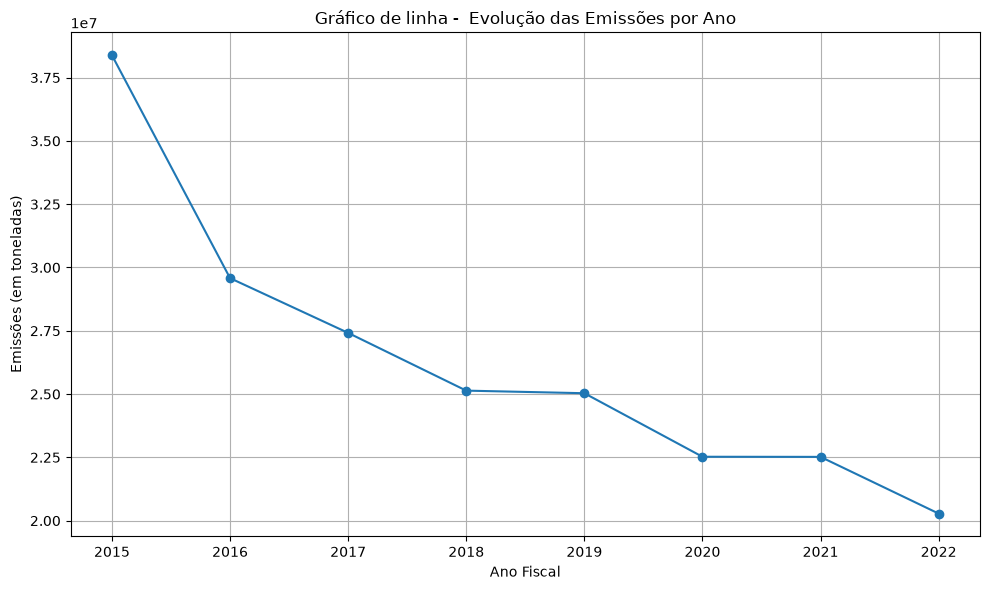

In [10]:
#Gráfico para pergunta fechada: "Houve redução nas emissões ao longo dos anos?"

plt.figure(figsize=(10,6))
plt.plot(emissoes_anuais['Fiscal Year'], emissoes_anuais['Emissions'], marker='o')

plt.title('Gráfico de linha -  Evolução das Emissões por Ano')
plt.xlabel('Ano Fiscal')
plt.ylabel('Emissões (em toneladas)')
plt.grid(True)
plt.tight_layout()

plt.show

**Análise do Gráfico**

Entre o período de 2015 e 2022 a empresa Apple experimentou uma queda em suas emissões de gases do efeito estufa, com 2015 apresentando um prelúdio promissor. Nos próximos anos a redução se manteve em um ritmo consistente até 2018, ano em que as reduções foram mais infímas. Após uma retomada na trajetória, outra situação similar ocorre em 2020, com uma redução mais tímida de 0,02%.

Como foi suposto anteriormente, houve uma redução mensurável dos gases emitidos pela empresa, o gráfico expõe isso de forma clara. Como pode-se observar, a linha tem um padrão de queda, com a maioria dos anos apresentando, senão uma eviedente redução, ao menos uma manutenção ou leve atenuação das emissões.

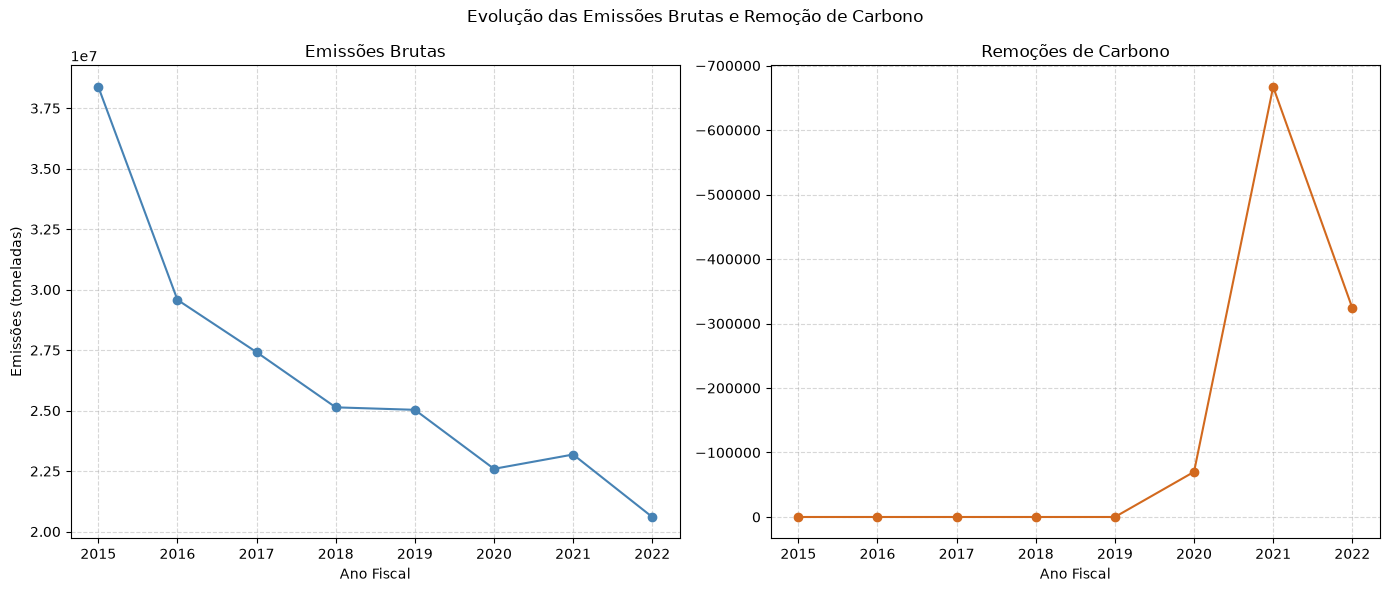

In [32]:
emissoes_brutas = df[df['Type'] == 'Gross emissions'].groupby('Fiscal Year')['Emissions'].sum().reset_index()
emissoes_brutas = emissoes_brutas.sort_values('Fiscal Year')

remocoes = df[df['Type'] == 'Carbon removals'].groupby('Fiscal Year')['Emissions'].sum().reset_index()
remocoes = remocoes.sort_values('Fiscal Year')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(emissoes_brutas['Fiscal Year'], emissoes_brutas['Emissions'], marker='o', label='Emissões Brutas', color='steelblue')
ax1.set_title('Emissões Brutas')
ax1.set_xlabel('Ano Fiscal')
ax1.set_ylabel('Emissões (toneladas)')
ax1.grid(True, linestyle='--', alpha=0.5)


ax2.plot(remocoes['Fiscal Year'], remocoes['Emissions'], marker='o', color='chocolate')
ax2.set_title('Remoções de Carbono')
ax2.set_xlabel('Ano Fiscal')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.invert_yaxis()

fig.suptitle('Evolução das Emissões Brutas e Remoção de Carbono')
plt.tight_layout()
plt.show()

**Análise do Gráfico**

Para expandira análise, está separação dos gráfico por emissões e a remoção de carbono permite extrair dados importante para a análise. O gráfico da esquerda apresenta as emissões da empresa ao longo dos anos, porém, diferente do anterior, este não inclui as remoções de carbono, o aprofunda mais ainda a análise. O gráfico apresenta um comportamento similar ao anterior na maioria dos anos, contudo, **entre 2020 e 2021 houve um aumento nas emissões de gases**, que não foram capitados pelo gráfico anterior pois a empresa aumetou as remoções de carbono nesse período, compensando o crescimento das emissões. Enquanto no gráfico da esquerda, pode-se perceber como as remoções começaram mais tardias, com os primeiros registros a partir de **2019**, seguido por um pico em **2020** e, posteriormente, uma reduzida no ano seguinte. Logo seu padrão ainda é incerto. Contudo é possível afirmar que sua adesão contrinuiu de forma significativa para reduzir os níveis de emissões. 

Ademias, é importante ressaltar que a empresa não precisa cortar totalmente as emissões de gases até 2030, tendo as remoções de carbono como alternativa para ajudar a atingir a meta. 

In [30]:
import numpy as np
print(np.isinf(emissoes_brutas['Emissions']).sum())
print(np.isinf(remocoes['Emissions']).sum())

0
0


In [45]:
emissoes_2015 = df.loc[df['Fiscal Year'] == 2015]['Emissions'].sum()
emissoes_2022 =  df.loc[df['Fiscal Year'] == 2022]['Emissions'].sum()
reducao_pct = ((emissoes_2022 - emissoes_2015) / emissoes_2015) * 100

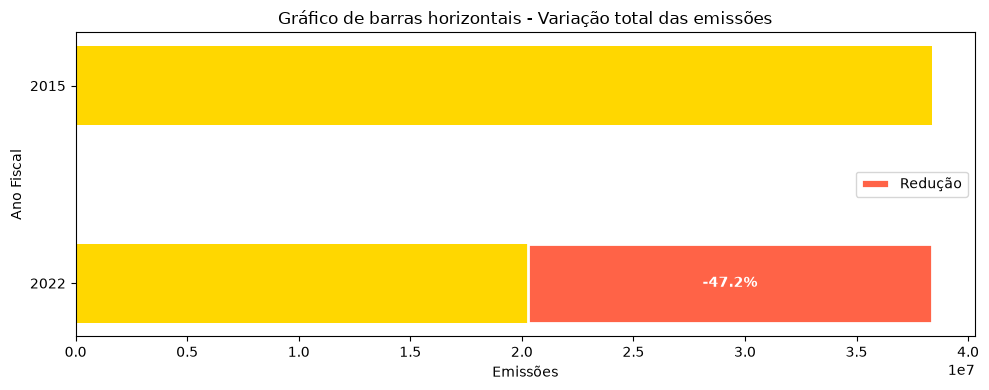

In [12]:
#Gráfico para perguntas fechadas:  "Qual foi a diferença percentual das emissões de gases ao longo do período analisado?"
xmax = max(emissoes_2015, emissoes_2022)
xmin = min(emissoes_2015, emissoes_2022)
diferenca = xmax - xmin
ymin = 0 if emissoes_2022 < emissoes_2015 else 1

plt.figure(figsize=(10,4))
plt.barh(['2022', '2015'], [emissoes_2022, emissoes_2015], color='gold', height=0.4)
plt.barh(ymin, diferenca, left=xmin, color='tomato', height=0.4, 
         label='Redução', edgecolor='white', linewidth=2)

plt.text(
    (xmin + xmax) / 2, ymin, 
    f'{reducao_pct:+.1f}%', 
    va='center', ha='center', fontsize=10, fontweight='bold', color='white'
)


plt.title('Gráfico de barras horizontais - Variação total das emissões')
plt.ylabel('Ano Fiscal')
plt.xlabel('Emissões')
plt.legend()
plt.tight_layout()

plt.show()

**Análise do Gráfico**

O gráfico acima demonstra a diferença percentual geral das emissões entre o primeiro ano da base de dados e o último que se tem regsitros. Por meio dele vemos uma redução expressiva nesses 7 anos, com a empresa atingindo a marca de **47,2%** das emissões reduzidas. Portanto, a hipótese de que a empresa apresentou apresentou níveis significativos de reduções percentuais é factual. 

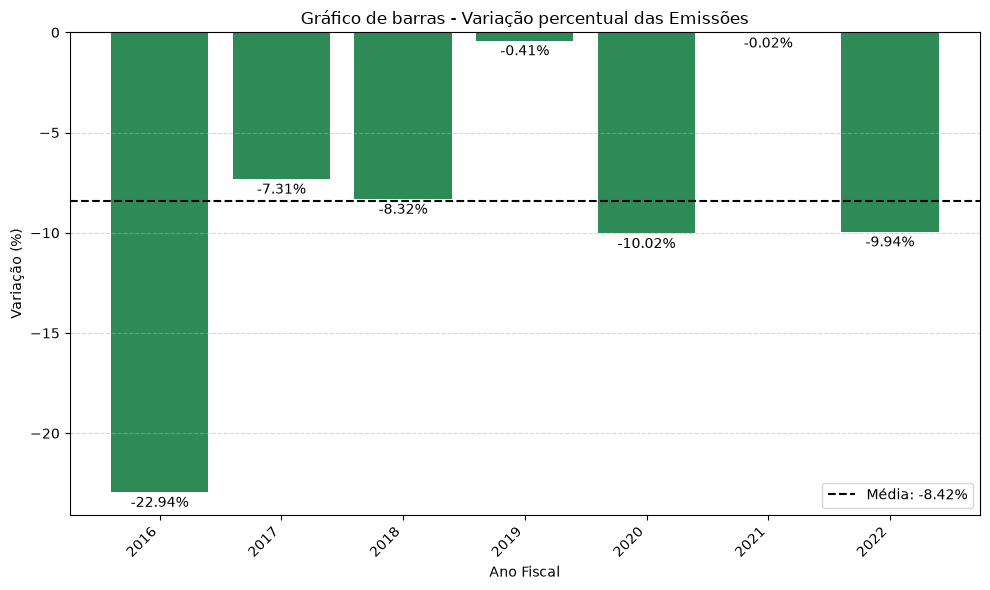

In [17]:
#Gráfico para perguntas fechadas: "Qual foi a diferença percentual das emissões de gases ao longo do período analisado?"
emissoes_anuais['var_pct'] = emissoes_anuais['Emissions'].pct_change() * 100
emissoes_var = emissoes_anuais.dropna(subset=['var_pct'])

layout = ['seagreen' if i > 0 else 'tomato' for i in dados['var_pct']]
media_var = emissoes_var['var_pct'].mean()

plt.figure(figsize=(10,6))
barras = plt.bar(emissoes_var['Fiscal Year'].astype(str), emissoes_var['var_pct'], color=layout)

plt.axhline(media_var, color='black', linestyle='--', linewidth=1.5, label=f'Média: {media_var:.2f}%')

plt.title('Gráfico de barras - Variação percentual das Emissões')
plt.xlabel('Ano Fiscal')
plt.ylabel('Variação (%)')
plt.bar_label(barras, fmt='%.2f%%', padding=3)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Análise do Gráfico**

O gráfico de barras demosntra a variação das reduções (em porcentagem) em cada ano. Através desse gráfico é visível que houve redução em todos os anos do período analisado, mesmo que menos significantes em alguns deles. 2016 obteve o maior percentual redutivo, com **22,94%** (embora não seja possível afirmar com certeza, a grande redução pode ser explicada por configurar o início dos esforços para diminuir as emissões de gases do efeito estufa). Enquanto em 2019 e 2021 as reduções foram menores, influenciando para a média de **8,42%** de redução anual

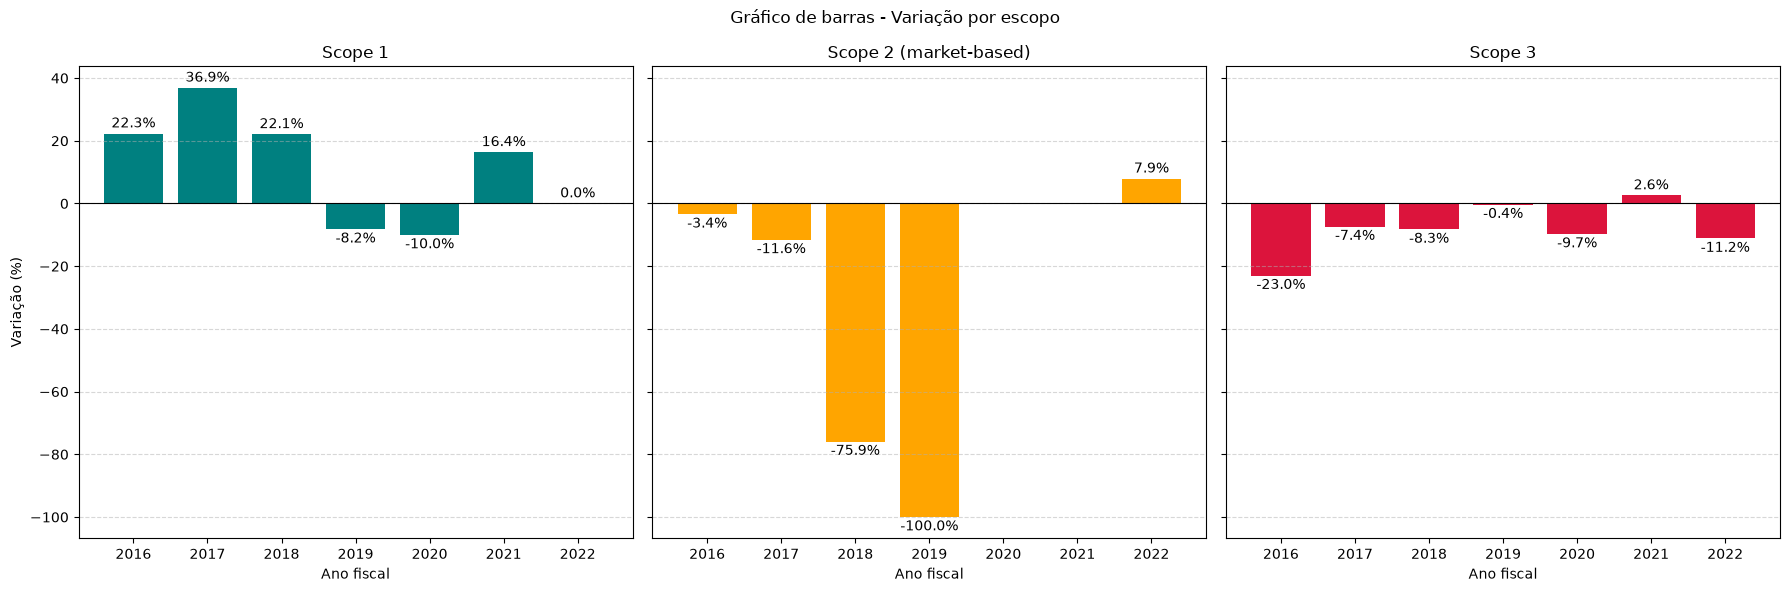

In [20]:
#Gráfico para pergunta fechada: "Quais áreas apresentaram maior/menor variação?"

emissoes_escopo = df.groupby(['Fiscal Year', 'Scope'])['Emissions'].sum().reset_index()

tabela_pivot = emissoes_escopo .pivot(index='Fiscal Year', columns='Scope', values='Emissions')
var = tabela_pivot.pct_change() * 100
var = var.dropna(how='all')

ano = var.index.astype(str)
escopo = var.columns
n_escopo = len(escopo)
tam_barra = 0.8 / n_escopo
x = np.arange(len(ano))

fig, eixos = plt.subplots(1, n_escopo, figsize=(18, 6), sharey=True)
layout = ['teal', 'orange', 'crimson']

for i, scp in enumerate(escopo):
    ax = eixos[i]
    barras = ax.bar(ano, var[scp], color=layout[i])
    ax.bar_label(barras, fmt='%.1f%%', padding=2, fontsize=10)

    ax.set_title(scp)
    ax.set_xlabel('Ano fiscal')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
eixos[0].set_ylabel('Variação (%)')

fig.suptitle('Gráfico de barras - Variação por escopo')
plt.tight_layout()

plt.show()

**Análise do Gráfico**

Com a análise de variação percentual dividida em escopos, podemos analisar o comportamento mais aprofundado ao demonstrar que o comportamento das emissões varia entre as categorias. 

O *Scope 1* foi o que apresentou a menor redução dentre os escopos. No começo do  as emissões seguem subindo, com entre  **22,1%** e **36,9%** a mais que no ano anterior por três anos, até que em 2019 as emissões começam a diminuir, com próximos dois anos reduzindo **8,2%** e **10%** das emissões. Em seguida, 2021 retoma os aumentos, com mais de **16%** de elevação nas emissões. Por fim 2022 não apresentou variação nas emissões comparado ao ano anterior. Em suma, as reduções do primeiro escopo naõ conseguiram superar os aumentos, contudo, contudo, sendo uma parcela menos significativa, não afetou de forma significativa o todo.

Enquanto o *Scope 2* iniciou com reduções crescentes a cada anos, começando com **3,4%** em 2019, depoiis **11,6%** e **75,9%** nos anos seguintes,atingindo **100%** em 2019, ou seja, aquela área não emitia mais nenhum gás do efeito estufa. Contudo, há um pequeno retorno das emissões wm 2022. O segundo escopo foi o que apresentou o melhor desempenho percentual, o que demonstra que os esforço surtiram efeito nessa área, apesar do singelo retorno.

O *Scope* 3, por sua vez, responsável pela maior parcela das emissões, apresenta papel particularmente relevante na evolução do total, enquanto os *Scopes* 1 e 2 apresentam maior oscilação. A continuidade da redução no Scope 3, por concentrar a maior parte das emissões, tende a ser especialmente relevante para o alcance das metas ambientais da empresa. Seu comportamento é o que mais influência as emissões gerais, seu padrão sendo similar ao gráfico anterior: no primeiro ano, 2015, uma diminuição mais siginificativa, **23%**, em seguida, os próximos anos mantém um ritmo entre **7%** e **8,5%** até 2019, onde as reduções foram menores. Após uma retomada no ritmo em 2020, as emissões passaram a subir, com um aumento de **2,6%**, que logo foram reprimidas por uma queda de mais de **11,2%**. Ou seja, apesar do aumento entre 2020-2021, o terceiro escopo apresentou padrão de redução nas emissões.

Devido ao **Scope 3** ser a área com a maior concentração das emissões, o foco neste setor tem grande influência sobre os resultados da empresa em atingir seu objetivo.

##### **CONCLUSÃO**

**Perguntas fechadas**

- Houve redução nas emissões ao longo dos anos?<br>
O histórico demonstra a trajetória de redução das emissões, indicando que as iniciativas adotadas durante o período produziram resultados mensuráveis.

- Qual foi a diferença percentual das emissões de gases ao longo do período analisado?<br>
aproximadamente -47,2%, embora não tenha sido constante, apresentou um resultado relevantes.

- Quais anos apresentaram as maiores reduções (ou aumentos) nas emissões?<br>
Maiores: 2016: -22,94%; 2016 trouxe resultados importantes, mas junto a ele a dúvida do porquê esse valores não foram mantido<br>
Menores: 2019: -0,41% e 2021: -0,02%; esses períodos de baixa redução merecem investigação, pois podem indicar limitações ou mudanças na efetividade das iniciativas de redução.

- Quais áreas apresentaram maior/menor variação?<br>
O *Scope 3* é o escopo mais relevante em volume de emissões e apresenta o comportamento mais consistente. Portanto ações direcionadas às fontes desse escopo possuem maior potencial de impacto sobre as emissões totais. Além disso, o segundo escopo e seu retorno merece um detaque e pesquisas à parte.

Dessa forma, respondendo a pergunta:<br>
**A empresa apresentou reduções nas emissões ao longo do perídodo analisado?** <br>
Sim. A empresa apresentou redução contínua das emissões entre 2015 e 2022, com uma redução acumulada de aproximadamente 47,2% no período.

---
#### Partindo para a segunda pergunta:

2. **A Apple está no ritmo necessário para atingir a meta de carbono zero até 2030?**

- Qual foi o ritmo histórico de redução das emissões entre 2015 e 2022?
- Mantendo o ritmo histórico, qual seria a projeção das emissões para 2030?
- Qual ritmo de redução seria necessário para atingir a meta em 2030?

Para verificar o ritmo histórico das reduções, podemos utilizar do CAGR (taxa de crescimento/redução composta anual), que responde a pergunta de qual é a taxa constante, aplicada ao ano, leva as emissões de 2015 as emissões de 2022. Dessa forma, identificando qual seria o rumo das emissões se a empresa seguisse a mesma média das reduções apresentadas anteriormente.

Além disso, há como identificar qual seria a trajetória ideal para atingir a meta de carbono zero e comparar com o desempenho da empresa.

In [15]:
#Taxa médiua anual da reduçõa das emissões

taxa_anual = 1 - ((emissoes_2022/emissoes_2015) ** (1/7))
print(f'{taxa_anual*100:.2f}%')

8.71%


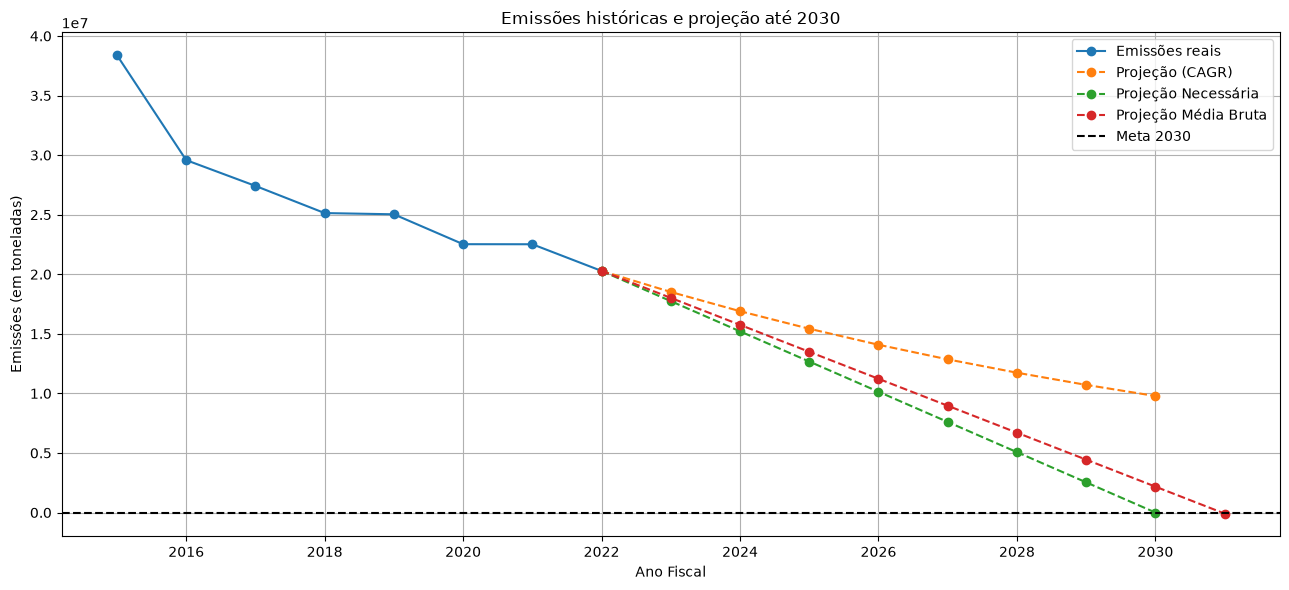

In [75]:
#Anos
anos_reais = list(range(2015,2023))
anos_proj = list(range(2022,2031))
n_anos = 2030-2022
ano2031 = list(range(2022,2032))

#Emissões reais
emissoes_reais = list(emissoes_anuais['Emissions']) 

#Emissões projetadas com o CAGR
emissoes_proj = [emissoes_2022]

for i in range(8):
    proxe = emissoes_proj[-1] * (1 - taxa_anual)
    emissoes_proj.append(round(proxe, 2))

#Emissões projetadas Ideal
reducao_anual_ideal = emissoes_2022 / n_anos
emissoes_proj_ideal = [round(emissoes_2022 - (reducao_anual_ideal * i), 2) for i in range(n_anos + 1)]

#Emissões projetadas Média Produto Bruto
reducao_anual_bruto = (emissoes_2015-emissoes_2022)/n_anos
emissoes_proj_bruto = [round(emissoes_2022 - (reducao_anual_bruto * i), 2) for i in range(n_anos+2)] 


plt.figure(figsize=(13,6))

plt.plot(anos_reais, emissoes_reais, marker='o', label='Emissões reais')
plt.plot(anos_proj, emissoes_proj, marker='o', linestyle='--', label='Projeção (CAGR)')
plt.plot(anos_proj, emissoes_proj_ideal, marker='o', linestyle='--', label='Projeção Necessária')
plt.plot(ano2031, emissoes_proj_bruto, marker='o', linestyle='--', label='Projeção Média Bruta')


plt.axhline(0, linestyle='--',label='Meta 2030', color='black')

plt.title('Emissões históricas e projeção até 2030')
plt.xlabel('Ano Fiscal')
plt.ylabel('Emissões (em toneladas)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

É importante ressaltar que essas projeções não refletem o real desempenho da empresa. Pela **projeção por CAGR**, matematicamente, seria impossível chegar a zero, essa projeção representa um cenário de redução percentual constante, no qual a mesma taxa é aplicada sobre as emissões do ano anterior. De todo modo, ainda é uma comparação relevante entre os esforços registrados e a projeção, que auxilia na análise do ritmo da empresa e identificar o que precisa ser feito. Enquanto a **projeção necessária** e de **média bruta** apresentam cenários teóricos, muito úteis para entender os rumos que devem ser tomado para atingir a meta da empresa. Dessa forma, não apenas com a visualização dos gráficos, mas com um pensamento analítico, é possível extrair *insights* importantes dessa avaliação.

**Análise do Gráfico**

Embora as projeções utilizem premissas diferentes, sua comparação permite avaliar a distância entre o ritmo histórico de redução e o ritmo necessário para atingir a meta. Porém fica explícito que, mesmo nos primeiros anos da projeção, se as reduções se mantiverem no mesmo ritmo (média composta das reduções anuais), não será o suficiente para atingir a meta de carbono zero até 2030. 

Redução média atual (**8,71%**) <br>
Redução média ano 1 (**12,5%**)

Além disso, mesmo ao comparar a redução média, é possível obervar que, se a empresa mantiver a mesma redução constante até o ano de 2030, não terá atingido a meta de carbono 0. 

Como a nálise foi feita:
A **projeção CAGR (linha laranja)** faz uma estimativa em cima de uma porcentagem, logo, a redução bruta diminui a cada ano. Enquanto a **projeção ideal (linha verde)** é ao contrário, ela calcula qual deve ser a redução bruta anualmente para atingir a meta e projeta uma porcentagem redutiva para cada ano, fazendo com que essa porcentagem aumente com o passar o tempo, pois a mesma quantidade passa a representar uma parcela maior. Por sua vez, a **projeção da média (linha vermelha)** bruta busca responder qual será a redução se o ritmo de mantiver, com sua base sendo a média simples das reduções brutas ao longo do histórico, logo, assim como a anterior, exibir um redução percentual maior a cada ano.  

Com o tempo, reduzir muitas emissões pode, ou não, se tornar mais desafiador, isso depende das atividades e abordagens da empresa. Contudo, ao seguir um padrão linear (como na projeção ideal) é preciso que o percentual aumente, pois, no ano seguinte, para reduzir aquela mesma quantidade de gases (bruto) seria necessária um percentual maior que o anterior, o que não foi o visto nas reduções anuais apresentadas no gráfico da primeira pergunta.


In [76]:
taxa_necessaria_ano1 = abs((emissoes_proj_ideal[1] - emissoes_proj_ideal[0]) / emissoes_proj_ideal[0]) * 100

print(f'Redução atual: {reducao_anual_bruto:,.2f} toneladas/ano')
print(f'Redução necessária: {reducao_anual_ideal:,.2f} toneladas/ano')

print(f'\nRedução percentual atual: {taxa_anual*100:.2f}% a.a.')
print(f'Redução percentual necessária: {taxa_necessaria_ano1}% a.a. (no primeiro ano)')

Redução atual: 2,262,946.25 toneladas/ano
Redução necessária: 2,534,987.50 toneladas/ano

Redução percentual atual: 8.71% a.a.
Redução percentual necessária: 12.5% a.a. (no primeiro ano)


##### **CONCLUSÃO**

- Qual foi o ritmo histórico de redução das emissões entre 2015 e 2022?<br>
Segundo o CARG, a média redutiva foi de 8,71% a.a.. <br>
Enquanto, para a média das emissões, a redução bruta foi de 2,26 milhões de toneladas a.a..

- Mantendo o ritmo histórico, qual seria a projeção das emissões para 2030? <br>
Observamos dois cenários, um deles a projeção ficava abaixo de 10mi, no segundo, atingia por volta de 2,5mi, ou seja, em nenhuma das opções, a meta fora atingida.

- Qual ritmo de redução seria necessário para atingir a meta em 2030?<br>
Ao analisar a redução bruta, o ritmo deve ser de 2,53mi de toneladas a.a., sendo isso 12,5% das emissões no primeiro ano, projeções que estão acima da esperada.

Dessa forma, respondendo a pergunta:<br>
**A Apple está no ritmo necessário para atingir a meta de carbono zero até 2030?** <br>
Com base no ritmo histórico observado entre 2015 e 2022, a empresa não estaria no ritmo necessário para atingir a meta de emissões zero até 2030 caso mantivesse esse mesmo padrão de redução, indicando a necessidade de intensificar as ações de redução. Contudo, vale ressaltar que não apenas diminuir as emissões é a única abordagem, como visto em análises anteriores, remoções de gases a até compensações podem ajudar a empresa a atingir essa meta

---
#### Partindo para a próxima pergunta:

3. **A diminuição (se houver) das emissões teve impacto no crescimento econômico da empresa?**

Já sabemos, pela análise anterior que houve redução nas emissões, mas será que isso afetou o crescimento econômico da empresa?

- Qual foi a taxa média de crescimento da receita e do valor de mercado entre 2015 e 2022, e como esse crescimento variou ao longo do período?
- Como a receita e o valor de mercado evoluíram enquanto as emissões diminuíram?
- Há uma relação entre a evolução das emissões e o desempenho econômico da empresa?

In [29]:
nf = pd.read_csv('apple_emissions/normalizing_factors.csv')

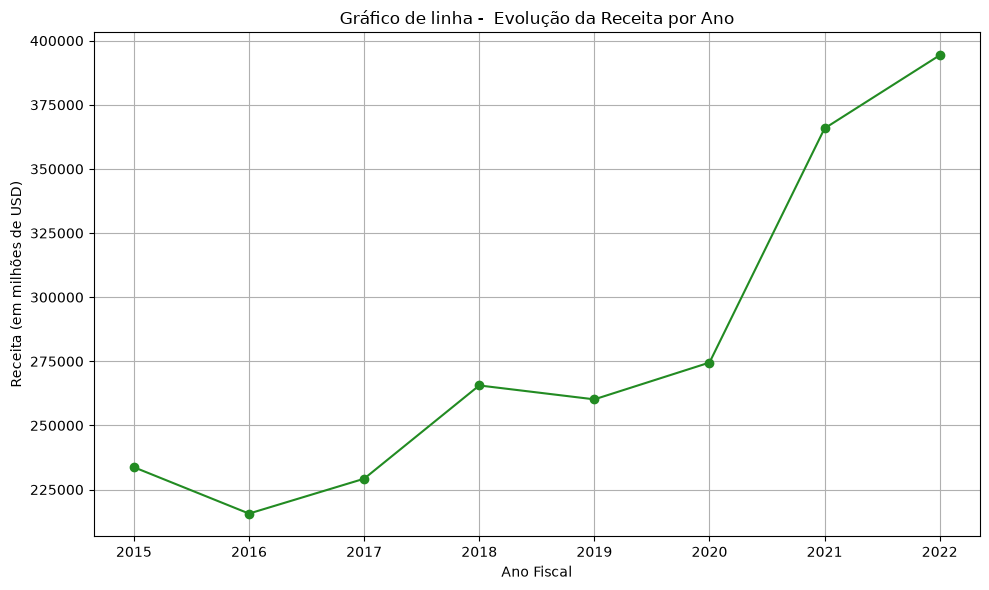

In [26]:
#Gráfico para a pergunta 'Há uma relação entre a evolução das emissões e o desempenho econômico da empresa?'

plt.figure(figsize=(10,6))
plt.plot(nf['Fiscal Year'], nf['Revenue'], marker='o', color='forestgreen')

plt.title('Gráfico de linha -  Evolução da Receita por Ano')
plt.xlabel('Ano Fiscal')
plt.ylabel('Receita (em milhões de USD)')
plt.grid(True)
plt.tight_layout()

plt.show()

In [61]:
cagr_receita = ((nf['Revenue'][0]/ nf['Revenue'][7])**(1/7) -1)*100
aumento_2020 = (nf['Revenue'][1] - nf['Revenue'][2])/nf['Revenue'][1]*100

print(f'média por taxa de crescimento composta: {cagr_receita:.2f}%')
print(f'aumento de 2020 -> {aumento_2020:.2f}%')

média por taxa de crescimento composta: 7.76%
aumento de 2020 -> 24.96%


**Análise do Gráfico**

Através deste gráfico é possível esxtrair algumas observações relevantes. Obsevando o comportamento da receita: a empresa começa o relatório com uma pequena retração em 2015, mas se recupera nos anos seguintes, incluindo um crescimento expressivo em 2018. Em seguida mais uma leve queda em 2019, mas, a partir de 2020, a Apple entra em uma trajetória de crescimento mais acentuada, especialmente em 2021, saindo de aproximadamente USD 274 bilhões para mais de USD 360 bilhões.

Para e xtrair mais informações, podemos comparar a redução das emissões e o crescimento da receita em um único gráfico. Para isso é necessário que os valores do eixo Y sejam ajustados, para que ao invés de fazer uma comparação de milhões de USD com tonelas de CO2, podemos comparar através da mesma métrica. Para isso utilizo a base 100 como referência para ambas as métricas.

In [34]:
receita_anual = nf.groupby('Fiscal Year')['Revenue'].sum().reset_index()

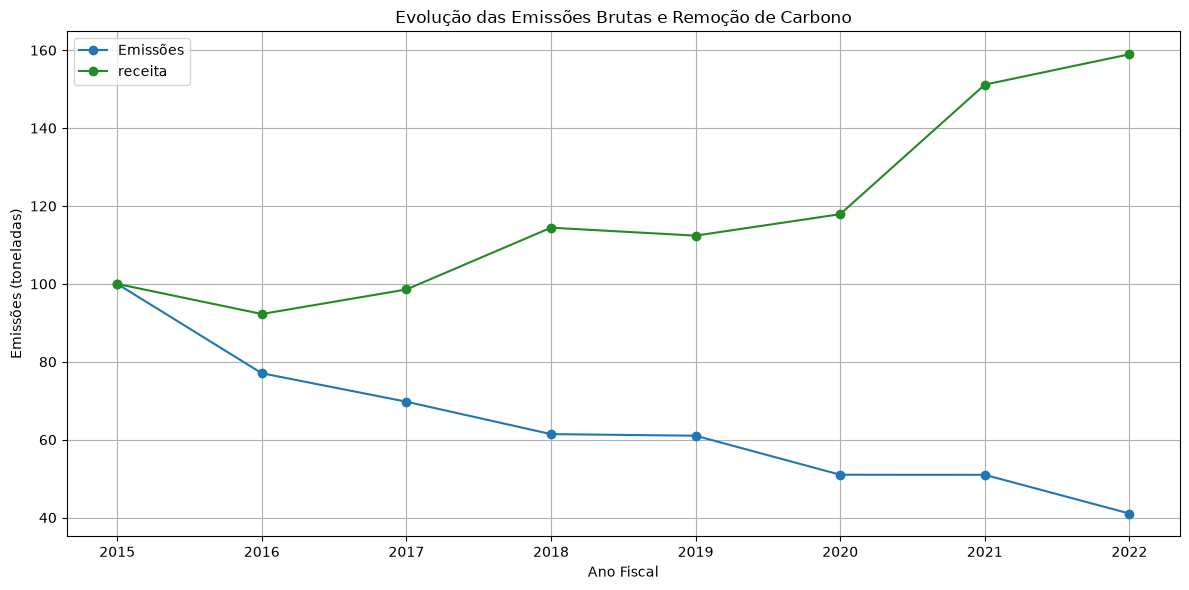

In [36]:
#Gráfico para a pergunta: 'Como a receita e o valor de mercado evoluíram enquanto as emissões diminuíram?'Como a receita e o valor de mercado evoluíram enquanto as emissões diminuíram?'

#Variação percentual das emisões
emissoes_anuais['var_pct'] = emissoes_anuais['Emissions'].pct_change()*100
var_emissoes = list(emissoes_anuais['var_pct'].dropna())
var_e = [100]

for e in var_emissoes:
    var_e.append(round(var_e[-1] + e, 2))

receita_anual['var_pct'] = receita_anual['Revenue'].pct_change()*100
var_receita= list(receita_anual['var_pct'].dropna())
var_r = [100]

for r in var_receita:
    var_r.append(round(var_r[-1] + r, 2))

plt.figure(figsize=(12, 6))

plt.plot(emissoes_anuais['Fiscal Year'], var_e, marker='o', label='Emissões')
plt.plot(receita_anual['Fiscal Year'], var_r, marker='o', label='receita', color='forestgreen')

plt.title('Evolução das Emissões Brutas e Remoção de Carbono')
plt.xlabel('Ano Fiscal')
plt.ylabel('Emissões (toneladas)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Análise do Gráfico**

AO comparar a **linha das emissões (azul)** e a **linha da receita (verde)**, há algumas informações que pode-se extrair deste gráfico. No começo dos registros as emissões e a receita apresentaram um comportamento divergente, com a receita aumentando, ao passo que as emissões diminuiam. Contudo, após 2020, o padrão é quebrado com um crescimento significativo da receita, enquanto as emissões mal apresentaram redução mensurável. Após isso o padrão se seguiu semelhante. 

Isso não significa que a redução nas emissões foram um dos fatores para o crescimento econômico da empresa, mas a análise comprova que essa redução não foi acompanhada por uma queda consistente no desempenho econômico. 

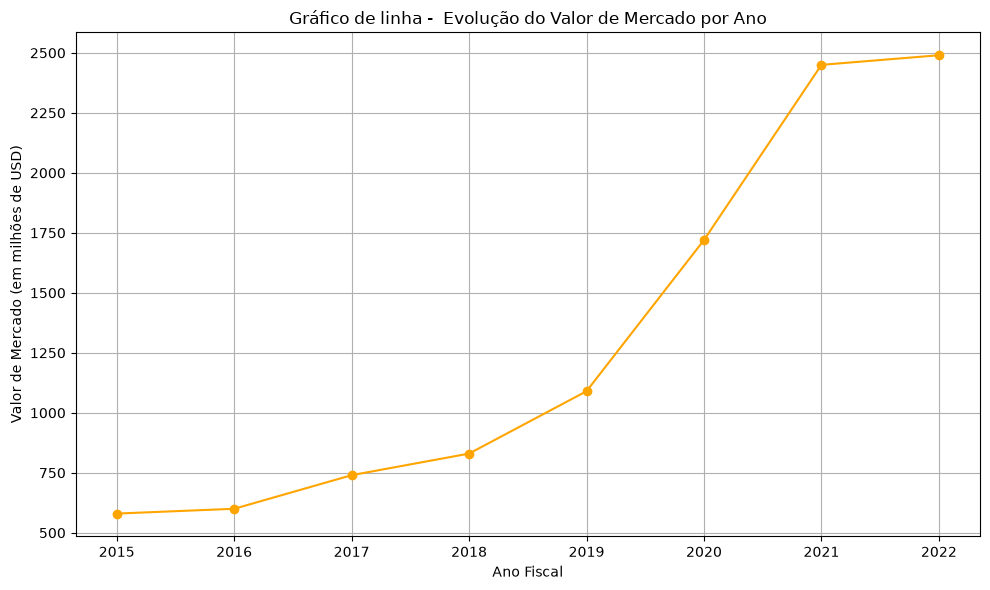

In [154]:
plt.figure(figsize=(10,6))
plt.plot(nf['Fiscal Year'], nf['Market Capitalization'], marker='o', color='orange')

plt.title('Gráfico de linha -  Evolução do Valor de Mercado por Ano')
plt.xlabel('Ano Fiscal')
plt.ylabel('Valor de Mercado (em milhões de USD)')
plt.grid(True)
plt.tight_layout()

plt.show()

In [180]:
evolucao_pct_vm = (nf['Market Capitalization'][0] / nf['Market Capitalization'][7]) * 100
print(f'{evolucao_pct_vm:.2f}%')

429.31%


**Análise do Gráfico**

O valor de mercador começou com um crescimento menos expressivo entre os anos de 2015 a 2017, mas em 2018 inicou-se uma escalada do valor da empresa, com aumentos significativos dentro dos próximos anos até 2021, quando o valor comercial passa por um crescimento mais agudo. Isso demonstra que **a redução das emissões não comprometeu o valor de mercado da empresa**, pois esse crescimento deu-se em um período em que as emissões reduziran, no total, mais de **47%**, enquanto o valor de mercado aumentou em mais **429%**.

**Comportamento de 2020**

Além de comprovar que a redução as emissões não provocou prejuízos econômicos a empresa, é possível extrair outro *insight* curioso destes gráficos. Entre os anos de 2020 a 2021 ambos os gráficos apresentam comportamento distinto, sendo o ano com maior aumento na receita, um crescimento no valor de mercado acima da maioria, porém, com uma queda nas reduções de gases daquele ano. Isso não significa que essas informações não estejam necessariamente relacionadas, mas que provavelmente, um fator externo daquela época - como por exemplo, um aumento na demanda - afetou o desempenho da empresa e as emissões de gases. Contudo, seriam necessários mais dados para comprovar qualquer hipótese.

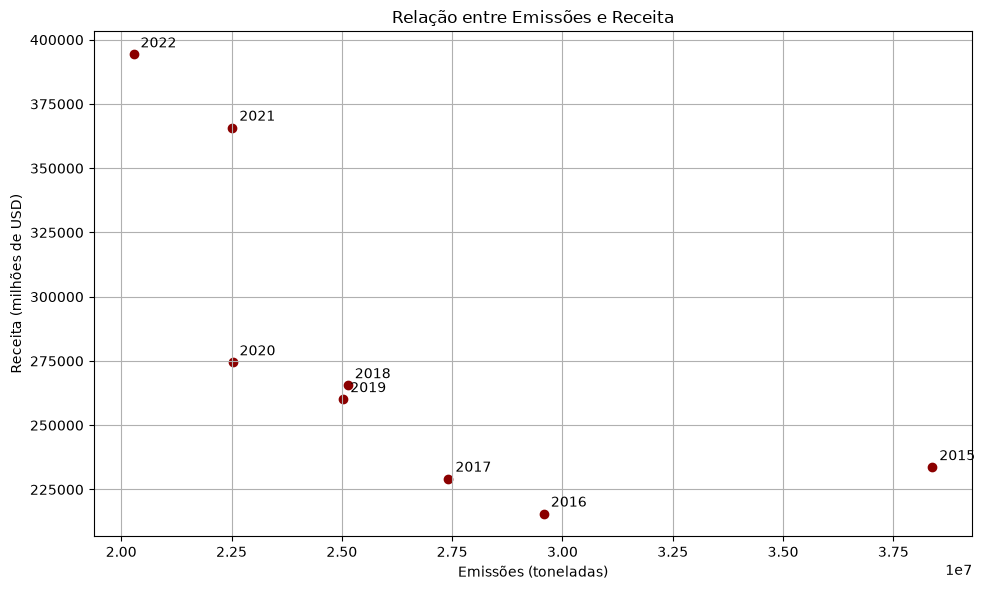

In [25]:
#Gráfico para a pergunta 'Há uma relação entre a evolução das emissões e o desempenho econômico da empresa?'

emissoes_receita = sql("""
    SELECT
        ge.`Fiscal Year` AS ano,
        SUM(ge.Emissions) AS emissions,
        nf.Revenue AS revenue
    FROM gas_emissions AS ge
    INNER JOIN normalizing_factors AS nf
        ON ge.`Fiscal Year` = nf.`Fiscal Year`
    GROUP BY ge.`Fiscal Year`, nf.Revenue
    ORDER BY ano;
""")

plt.figure(figsize=(10,6))

plt.scatter(emissoes_receita['emissions'], emissoes_receita['revenue'], color='darkred')

#Para indicar o ano
for _, linha in emissoes_receita.iterrows():
    plt.annotate(int(linha['ano']), (linha['emissions'], linha['revenue']),xytext=(5, 5), textcoords='offset points')

plt.title('Relação entre Emissões e Receita')
plt.xlabel('Emissões (toneladas)')
plt.ylabel('Receita (milhões de USD)')

plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
correlacao = emissoes_receita['emissions'].corr(emissoes_receita['revenue'])
print(f'Correlação: {correlacao:.2f}')

Correlação: -0.68


**Análise do Gráfico**

O gráfico de dispersão ajuda a entender a correlação entre as emissões e a receita. Após analisar o comportamento dos gráficos de linhas, através da **estatística**, pode-se verificar o efeito de causalidade desses valores. Entretanto há uma ressalva: uma amostra como há que se tem com apenas 8 anos, isoladamente, corre o risco de ser influênciada por alguns dos anos. Entretando, ao observar a correlação, seu valor reflete uma **correção negativa**, que indica que as métricas são inversamente proporcionais. Em resumo, a estatística demonstra que **enquanto a emissões diminuem a receita aumenta**. Elas **não necessariamente são afetadas uma pela outra**, mas definitivamente a **diminuição das emissões não causou redução da receita**.

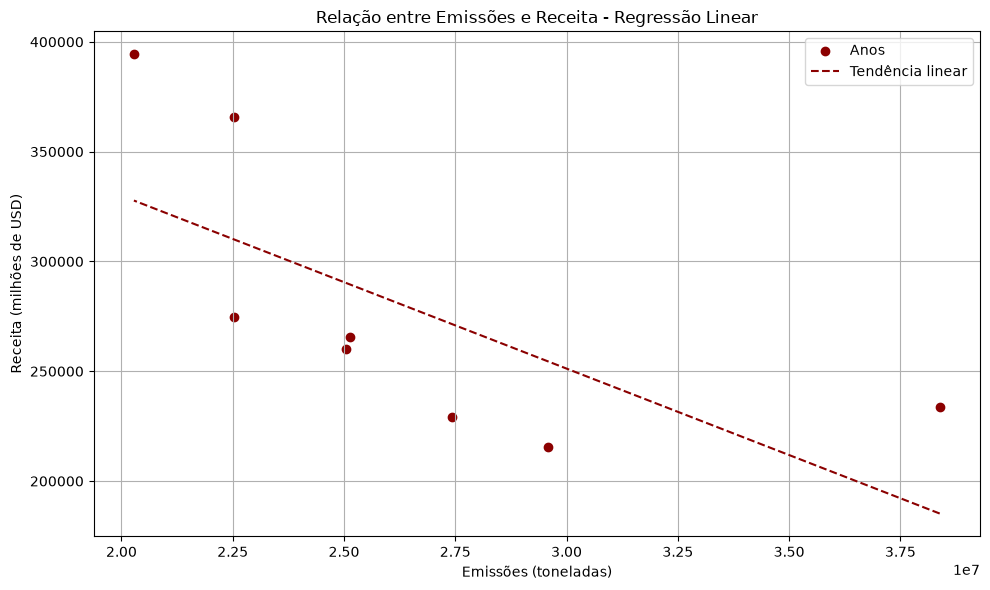

In [24]:
x = emissoes_receita['emissions']
y = emissoes_receita['revenue']

coef = np.polyfit(x, y, 1)
linha = np.poly1d(coef)

plt.figure(figsize=(10, 6))

plt.scatter(x, y, label='Anos', color='darkred')

plt.plot(x, linha(x), linestyle='--', label='Tendência linear', color='darkred')

plt.xlabel('Emissões (toneladas)')
plt.ylabel('Receita (milhões de USD)')
plt.title('Relação entre Emissões e Receita - Regressão Linear')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##### **CONCLUSÃO**

- Qual foi a taxa média de crescimento da receita e do valor de mercado entre 2015 e 2022, e como esse crescimento variou ao longo do período?
A receita teve um crecimento médio de **7,76%**, influenciador por crescimentos como o de quase **25%** em 2020.

- Como a receita e o valor de mercado evoluíram enquanto as emissões diminuíram?
Enquanto as emissões se mantiveram em queda durante o período analisado, a receita e o valor de mercado permaneceram com uma média **positiva**

- Há uma relação entre a evolução das emissões e o desempenho econômico da empresa?
Para que de fato fosse possível concluir se os esforço para diminuir as emissões tiveram algum efeito no desempenho econômico da empresa, seria necessário uma base de dados mais ampla, com valores além do período em que as reduções iniciaram. Contudo, pela análise realizada com os dados disponíveis, a empresa não obteve prejuízos significativos proveninetes da redução das emissões de gases do efeito estufa. 


Dessa forma, respondendo a pergunta:<br>
**A diminuição (se houver) das emissões teve impacto no crescimento econômico da empresa?**
Em geral, **não**, a empresa continuou lucrado em uma margem habitual, mesmo em períodos em que as emissões tiveram maiores quedas, sendo as emissões não o único fator a influenciar o desempenho econômico da empresa.

___
## 💡 Conclusão Geral da Análise

Neste documento foi analisado o desempenho da empresa Apple entre os anos de 2015 e 2022 em um projeto de redução das emissões de gases do efeito estufa com o objetivo de atingir a meta de carbono zero até 2030. Para isso, foram utilizados de ferramentas de análise de dados como Python (Matplotlib, Pandas, Numpy e Statistcs) para criação e visualização de gráficos, além de auxiliar em análise estatistícas; Banco de dados MySQL, que auxiliaram na manipulação da base de dados, permitindo extrair informações relevantes pra a análise; e com o auxiliuo de inteligência artificial em tarefas repetitivas e compreensão. Dessa forma, tornou-se possível extrair *insights* relevantes que responderam nossas perguntas de negócio.

Inicialmente, a análise foi dada pelas seguintes questões:

1. **A empresa apresentou reduções mensuráveis nas emissões ao longo do perídodo analisado?**
2. **A Apple está no ritmo necessário para atingir a meta de carbono zero até 2030?**
3. **A diminuição (se houver) das emissões teve impacto no crescimento ecocômico da empresa?**

E a análise passou por cada uma delas, pensando em perguntas fechadas que ajudariam a responder essas questões que foram condutoras da análise. Através delas pode-se extrair as seguintes conclusões: <br>

 As emissões da Apple apresentaram uma trajetória de queda no período analisado, com aproxidamente **42,7%** de redução nas emissões de gases. Com 2015-2016 apresentando o melhor desempenho, enquanto 2020-2021 tiverem reduções menores, ainda assim, todos os anos registraram diminuição nas emissões gerais. O *Scope 3* foi quem apresentou as maiores reduções brutas de emissões, e, pelo mesmo motivo, deve ser o foco dos esforços da empresa.

 Analisando o padrão da empresa baseando-se nos registros dos anos anteriores, a empresa não está no ritmo para atingir a meta de 2030. A Apple registrou uma média redutiva de **8,71% a.a.** nos anos entre 2015 e 2022, porém, só no primeiro ano (2023), a redução precisa atingir os **12,5%** e seguir aumentando até alcançar os 100%. Ou seja, apesar de não poder prever os resultados com exatidão, ao examinar o padrão, a empresa precisa aumentar as reduções se quiser atingir a meta de carbono zero até 2030.

 Apesar das reduções nas emissões, a Apple registrou um aumento médio de **7,76%** da receita, com uma queda significativa no início do registros e outra atenuação singela em 2018. Embora não haja dados do desempenho econômico da empresa de antes das reduções das emissões de gases, ao verificar o comportamento do valor de mercado e da receita da empresa, a emissões, isoladamente, não são reponsáveis por afetar o desempenho econômico da empresa.